# Heatmap

Heatmaps encode matrix values as colours; `plot_misc.heatmap` also supports annotating cells with formatted text.

## Standard heatmap

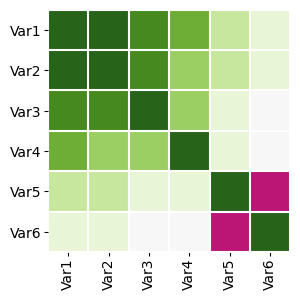

In [1]:
import matplotlib.pyplot as plt

import plot_misc.example_data.examples as examples
import plot_misc.heatmap as heatmap
import plot_misc.utils.utils as pm_utils

CMTOINCH = 1 / 2.54
cmap = plt.get_cmap("PiYG", 13)
norm = pm_utils.MidpointNormalize(vcenter=0, vmin=-1, vmax=1)

# getting the data
corr = examples.load_heatmap_preprocessed()

# plotting
fig, ax = plt.subplots(1, figsize=(8 * CMTOINCH, 8 * CMTOINCH))
im, _ = heatmap.heatmap(
    data=corr,
    row_labels=corr.index.to_list(),
    col_labels=corr.columns.to_list(),
    ax=ax,
    cmap=cmap,
    norm=norm,
    grid_linewidth=1.5,
)

# formatting
im.axes.tick_params(pad=1.5, length=3, bottom=True)
_ = im.axes.set_xticklabels(
    im.axes.get_xmajorticklabels(), rotation=90, va="center"
)

## Annotated heatmap

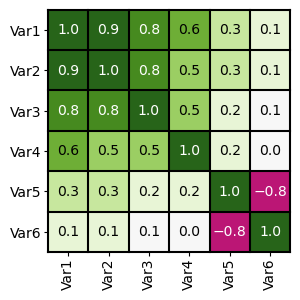

In [7]:
import matplotlib as mpl
import matplotlib.pyplot as plt

import plot_misc.example_data.examples as examples
import plot_misc.heatmap as heatmap
import plot_misc.utils.utils as pm_utils

CMTOINCH = 1 / 2.54

cmap = plt.get_cmap("PiYG", 13)
norm = pm_utils.MidpointNormalize(vcenter=0, vmin=-1, vmax=1)

# getting the data
corr = examples.load_heatmap_preprocessed()

# plotting
fig, ax = plt.subplots(1, figsize=(8 * CMTOINCH, 8 * CMTOINCH))
im, _ = heatmap.heatmap(
    data=corr,
    grid_col='black',
    row_labels=corr.index.to_list(),
    col_labels=corr.columns.to_list(),
    ax=ax,
    cmap=cmap,
    norm=norm,
    grid_linewidth=1.5,
)
# adding annotation
texts = heatmap.annotate_heatmap(
    im, threshold=0.7, valfmt="{x:.1f}", fontsize=10
)
# formatting
im.axes.tick_params(pad=1.5, length=3, bottom=True)
_ = im.axes.set_xticklabels(
    im.axes.get_xmajorticklabels(), rotation=90, va="center"
)

## Masked heatmap

`masked_heatmap` draws a single-colour background and overlays the heatmap only where a binary `indicator` table (same shape as `data`) equals `1`; the remaining cells stay in the background. Suppress the background lattice with `background_linewidth=0` and the cell outlines with `outline_linewidth=0`.

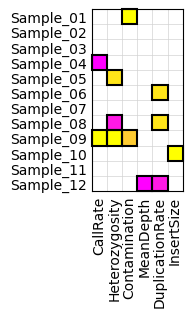

In [3]:
import matplotlib.pyplot as plt

import plot_misc.example_data.examples as examples
import plot_misc.heatmap as heatmap
import plot_misc.utils.utils as pm_utils

CMTOINCH = 1 / 2.54
cmap = plt.get_cmap("spring", 11)
norm = pm_utils.MidpointNormalize(vcenter=0, vmin=-3.5, vmax=3.5)

# QC values and a binary pass/fail indicator of the same shape
values, indicator = examples.get_data("qc_matrix")

# only the QC failures (indicator == 1) are drawn; the rest stay grey
fig, ax = plt.subplots(1, figsize=(4 * CMTOINCH, 6 * CMTOINCH))
im, _ = heatmap.masked_heatmap(
    data=values,
    indicator=indicator,
    row_labels=values.index.to_list(),
    col_labels=values.columns.to_list(),
    background_col="white",
    background_gridcol="lightgrey",
    background_linewidth=0.5,
    outline_col='black',
    outline_linewidth=1.5,
    outline_zorder=2,
    frame=True,
    cmap=cmap,
    norm=norm,
    ax=ax,
)
im.axes.tick_params(length=0, bottom=False)
_ = im.axes.set_xticklabels(
    im.axes.get_xmajorticklabels(), rotation=90, va="center"
)